In [4]:
!pip install imbalanced-learn

In [5]:
# --- PART 1: IMPORT SEMUA LIBRARY ---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings

# Mengabaikan warning yang tidak penting
warnings.filterwarnings('ignore')
# Set random seed untuk hasil yang konsisten
tf.random.set_seed(42)

print("Semua library berhasil di-import.")

Semua library berhasil di-import.


Memulai Pemuatan Data dan EDA...
Nama kolom berhasil dibersihkan (spasi dihapus).

Info Data (Tipe Data & Non-Null):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7

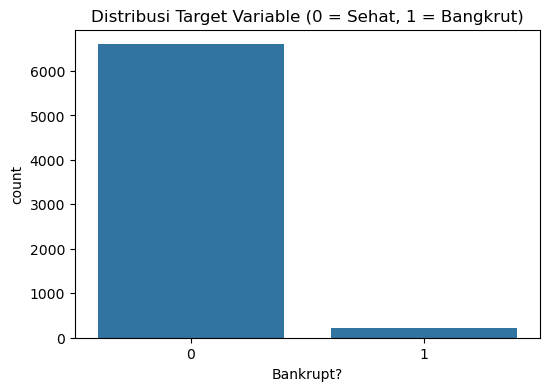

Membuat plot 'Boxplot ROA(C)'...


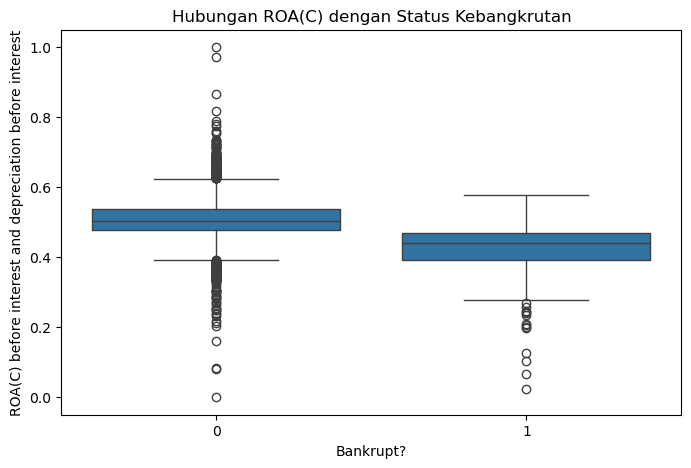

Membuat plot 'Histplot Debt ratio %'...


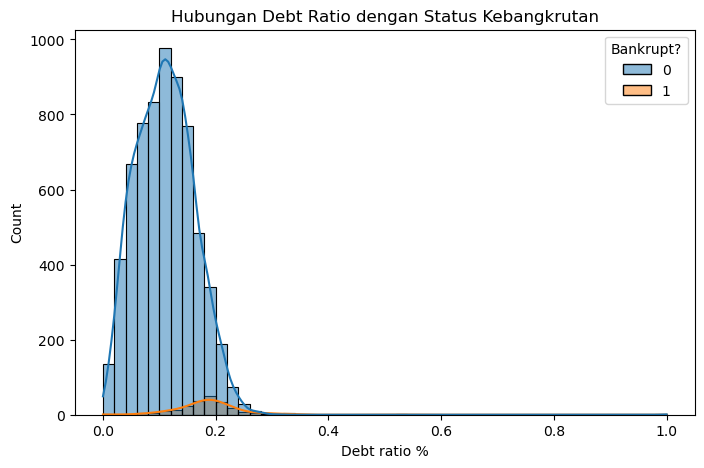


--- Langkah 2 Selesai ---


In [7]:
# --- PART 2: LANGKAH 2 - DATA UNDERSTANDING ---

print("Memulai Pemuatan Data dan EDA...")

try:
    # 1. Memuat data
    file_name = 'data-bank.csv'
    df = pd.read_csv(file_name)

    # 2. [PERBAIKAN] Membersihkan nama kolom (menghapus spasi di depan/belakang)
    df.columns = df.columns.str.strip()
    print("Nama kolom berhasil dibersihkan (spasi dihapus).")

    # 3. Menentukan Target Variable
    TARGET_COL = 'Bankrupt?'

    # 4. Menampilkan informasi dasar data
    print("\nInfo Data (Tipe Data & Non-Null):")
    df.info()

    print("\n5 Baris Pertama Data:")
    print(df.head())

    # 5. Cek distribusi target (Penting untuk Laporan Langkah 3)
    print(f"\nDistribusi Target Variable ({TARGET_COL}):")
    distribusi = df[TARGET_COL].value_counts()
    print(distribusi)
    print(f"Persentase Bangkrut: {distribusi[1] / (distribusi[0] + distribusi[1]) * 100:.2f}%")
    print("-> DATA SANGAT TIDAK BALANCE (IMBALANCED) <-\n")

    # 6. Visualisasi untuk Laporan
    print("Membuat plot 'Distribusi Target Variable'...")
    plt.figure(figsize=(6, 4))
    sns.countplot(x=TARGET_COL, data=df)
    plt.title('Distribusi Target Variable (0 = Sehat, 1 = Bangkrut)')
    plt.show()

    print("Membuat plot 'Boxplot ROA(C)'...")
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=TARGET_COL, y='ROA(C) before interest and depreciation before interest', data=df)
    plt.title('Hubungan ROA(C) dengan Status Kebangkrutan')
    plt.show()

    print("Membuat plot 'Histplot Debt ratio %'...")
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x='Debt ratio %', hue=TARGET_COL, kde=True, bins=50)
    plt.title('Hubungan Debt Ratio dengan Status Kebangkrutan')
    plt.show()

    print("\n--- Langkah 2 Selesai ---")

except FileNotFoundError:
    print(f"ERROR: File '{file_name}' tidak ditemukan. Harap pastikan file ada di folder yang sama.")
except Exception as e:
    print(f"ERROR saat memuat data: {e}")

In [8]:
# --- PART 3: LANGKAH 3 - DATA PREPARATION ---
# Pastikan sel Part 2 sudah dijalankan dan 'df' sudah ada.

print("\n--- Memulai Langkah 3: Data Preparation ---")

# 1. Penanganan Missing Values (Meskipun data ini bersih, ini adalah praktik yang baik)
for col in df.columns:
    if df[col].dtype == 'float64' or df[col].dtype == 'int64':
        df[col] = df[col].fillna(df[col].median())
print("Missing values (jika ada) telah diisi dengan median.")

# 2. Pemisahan Fitur (X) dan Target (y)
X = df.drop(TARGET_COL, axis=1)
y = df[TARGET_COL]

# 3. Simpan nama fitur untuk Langkah 6
feature_names = X.columns

# 4. Data Scaling (Penting untuk ANN dan SMOTE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_names)
print("Data berhasil di-scaling dengan StandardScaler.")

# 5. Menangani Imbalance Data dengan SMOTE (Oversampling)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("\nDistribusi target SETELAH SMOTE:")
print(y_resampled.value_counts())
print("-> Data sekarang sudah balance <-")

# 6. Train-Test Split (Gunakan data yang sudah di-resample)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

print(f"\nBentuk data latih (X_train): {X_train.shape}")
print(f"Bentuk data uji (X_test): {X_test.shape}")
print("--- Langkah 3 Selesai ---")


--- Memulai Langkah 3: Data Preparation ---
Missing values (jika ada) telah diisi dengan median.
Data berhasil di-scaling dengan StandardScaler.

Distribusi target SETELAH SMOTE:
Bankrupt?
1    6599
0    6599
Name: count, dtype: int64
-> Data sekarang sudah balance <-

Bentuk data latih (X_train): (10558, 95)
Bentuk data uji (X_test): (2640, 95)
--- Langkah 3 Selesai ---


In [9]:
# --- PART 4: LANGKAH 4 - MODELLING ---
# Pastikan sel Part 3 sudah dijalankan.

print("\n--- Memulai Langkah 4: Modelling ---")

# Model 1: Decision Tree
print("Melatih Model 1: Decision Tree...")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree selesai dilatih.")

# Model 2: Random Forest
print("\nMelatih Model 2: Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest selesai dilatih.")

# Model 3: Artificial Neural Network (ANN)
print("\nMelatih Model 3: Artificial Neural Network (ANN)...")
ann_model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = ann_model.fit(X_train, y_train,
                        epochs=50,
                        batch_size=32,
                        validation_split=0.2,
                        callbacks=[early_stop],
                        verbose=1)

print("ANN selesai dilatih.")
print("--- Langkah 4 Selesai ---")


--- Memulai Langkah 4: Modelling ---
Melatih Model 1: Decision Tree...
Decision Tree selesai dilatih.

Melatih Model 2: Random Forest...
Random Forest selesai dilatih.

Melatih Model 3: Artificial Neural Network (ANN)...
Epoch 1/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8398 - loss: 0.4030 - val_accuracy: 0.9072 - val_loss: 0.2390
Epoch 2/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8920 - loss: 0.2837 - val_accuracy: 0.9252 - val_loss: 0.2070
Epoch 3/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9126 - loss: 0.2379 - val_accuracy: 0.9403 - val_loss: 0.1775
Epoch 4/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9247 - loss: 0.2117 - val_accuracy: 0.9489 - val_loss: 0.1560
Epoch 5/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9364 - loss: 0.1926 - val_accuracy: 0.9560 - val_loss: 0.1440
Epoch 6/50
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9464 - loss: 0.1647 - val_accuracy: 0.9631 - val_loss: 0.1224
Epoch 7/50


--- Memulai Langkah 5: Evaluation ---
Membuat prediksi...
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

     HASIL EVALUASI MODEL

--- 1. Decision Tree ---
              precision    recall  f1-score   support

   Sehat (0)       0.96      0.94      0.95      1320
Bangkrut (1)       0.95      0.96      0.95      1320

    accuracy                           0.95      2640
   macro avg       0.95      0.95      0.95      2640
weighted avg       0.95      0.95      0.95      2640

Confusion Matrix - Decision Tree:


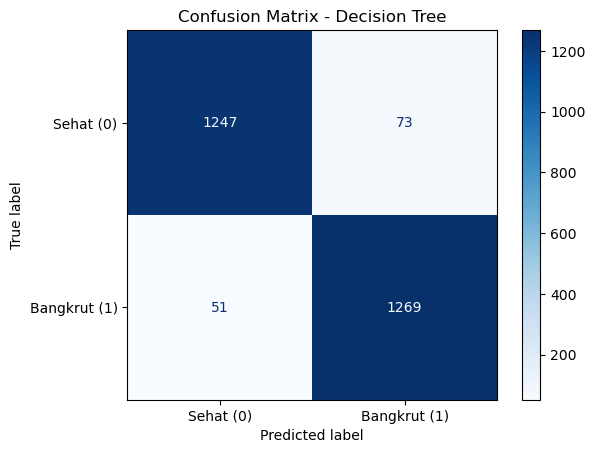


--- 2. Random Forest ---
              precision    recall  f1-score   support

   Sehat (0)       0.99      0.97      0.98      1320
Bangkrut (1)       0.97      0.99      0.98      1320

    accuracy                           0.98      2640
   macro avg       0.98      0.98      0.98      2640
weighted avg       0.98      0.98      0.98      2640

Confusion Matrix - Random Forest:


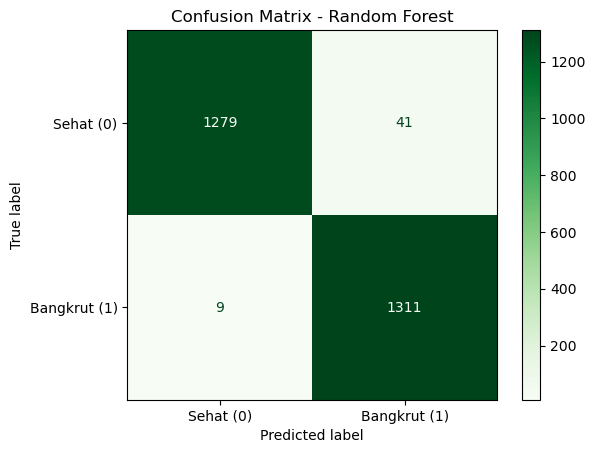


--- 3. Artificial Neural Network (ANN) ---
              precision    recall  f1-score   support

   Sehat (0)       1.00      0.97      0.99      1320
Bangkrut (1)       0.97      1.00      0.99      1320

    accuracy                           0.99      2640
   macro avg       0.99      0.99      0.99      2640
weighted avg       0.99      0.99      0.99      2640

Confusion Matrix - ANN:


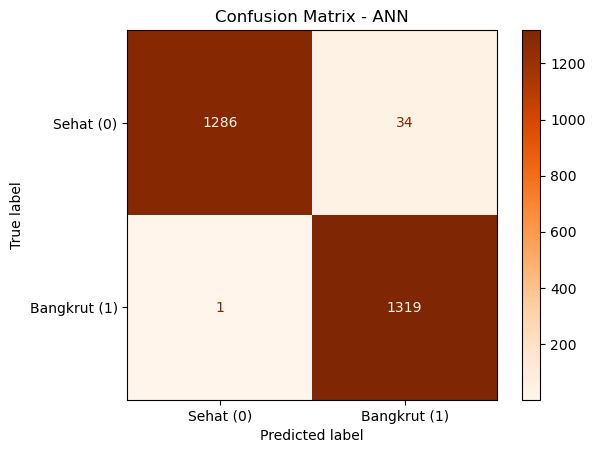

--- Langkah 5 Selesai ---


In [10]:
# --- PART 5: LANGKAH 5 - EVALUATION ---
# Pastikan sel Part 4 sudah dijalankan.

print("\n--- Memulai Langkah 5: Evaluation ---")

# 1. Dapatkan prediksi dari setiap model
print("Membuat prediksi...")
y_pred_dt = dt_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

y_pred_prob_ann = ann_model.predict(X_test)
y_pred_ann = (y_pred_prob_ann > 0.5).astype(int).flatten()

# 2. Tampilkan Laporan Evaluasi
target_names = ['Sehat (0)', 'Bangkrut (1)']

print("\n" + "="*30)
print("     HASIL EVALUASI MODEL")
print("="*30)

# --- Evaluasi Decision Tree ---
print("\n--- 1. Decision Tree ---")
print(classification_report(y_test, y_pred_dt, target_names=target_names))
print("Confusion Matrix - Decision Tree:")
ConfusionMatrixDisplay.from_estimator(dt_model, X_test, y_test,
                                      display_labels=target_names,
                                      cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

# --- Evaluasi Random Forest ---
print("\n--- 2. Random Forest ---")
print(classification_report(y_test, y_pred_rf, target_names=target_names))
print("Confusion Matrix - Random Forest:")
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test,
                                      display_labels=target_names,
                                      cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.show()

# --- Evaluasi ANN ---
print("\n--- 3. Artificial Neural Network (ANN) ---")
print(classification_report(y_test, y_pred_ann, target_names=target_names))
print("Confusion Matrix - ANN:")
cm_ann = confusion_matrix(y_test, y_pred_ann)
disp_ann = ConfusionMatrixDisplay(confusion_matrix=cm_ann,
                                  display_labels=target_names)
disp_ann.plot(cmap='Oranges')
plt.title('Confusion Matrix - ANN')
plt.show()

print("--- Langkah 5 Selesai ---")


--- Memulai Langkah 6: Variabel Paling Berpengaruh ---
Mengambil 5 variabel paling berpengaruh dari model Random Forest...

Top 5 Variabel Paling Berpengaruh:
                                    Feature  Importance
85               Net Income to Total Assets    0.049284
39                     Borrowing dependency    0.049016
9      Continuous interest rate (after tax)    0.048179
18  Persistent EPS in the Last Four Seasons    0.045728
7               After-tax net Interest Rate    0.040947

Membuat plot 'Top 5 Variabel'...


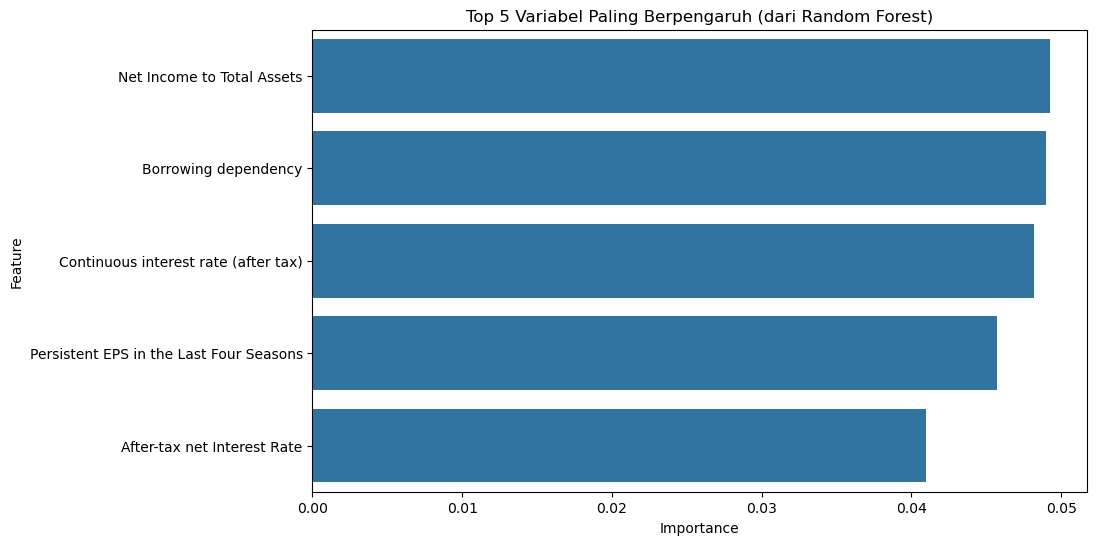

--- Langkah 6 Selesai ---

Analisis Selesai.


In [11]:
# --- PART 6: LANGKAH 6 - VARIABEL PALING BERPENGARUH ---
# Pastikan sel Part 4 sudah dijalankan.

print("\n--- Memulai Langkah 6: Variabel Paling Berpengaruh ---")
print("Mengambil 5 variabel paling berpengaruh dari model Random Forest...")

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names, # Diambil dari Part 3
    'Importance': importances
})

# Urutkan dari yang paling penting dan ambil 5 teratas
top_5_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(5)

print("\nTop 5 Variabel Paling Berpengaruh:")
print(top_5_features)

# Visualisasikan
print("\nMembuat plot 'Top 5 Variabel'...")
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_5_features)
plt.title('Top 5 Variabel Paling Berpengaruh (dari Random Forest)')
plt.show()

print("--- Langkah 6 Selesai ---")
print("\nAnalisis Selesai.")